In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

2026-02-05 07:57:14.437965: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 07:57:15.135040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 07:57:17.708820: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.p

## ML

In [2]:
"""
train_regime_model.py
---------------------
Train ONE regime model with horizon as a feature.
Model type is pluggable: Gradient Boosting or Neural Net.

This script:
- Uses deseasonalized VPD anomalies
- Trains on all horizons (1–12)
- Includes horizon explicitly as an input
- Trains ONE model for ONE target-month regime
"""


# =========================
# CONFIG
# =========================
CSV_PATH = Path("full_data.csv")
DATE_COL = "Yrmo"          # YYYYMM
TARGET_COL = "VPD"        # change to "VPD" if needed

MAX_HORIZON = 12
MODEL_TYPE = "nn"          # "gb" or "nn"

REGIME_NAME = "oct"
REGIME_MONTHS = {10}        # October

FEATURE_COLS = ["F1","F2","F3","F4","F5","F6"]        # set explicitly or auto-detect

RANDOM_STATE = 42
REGIME_DEFS = {
    "jan": {1},
    "feb": {2},
    "mar": {3},
    "apr": {4},
    "may": {5},
    "jun": {6},
    "jul": {7},
    "aug": {8},
    "sep": {9},
    "oct": {10},
    "nov": {11},
    "dec": {12},
}

all_results = []


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)

df["date"] = pd.to_datetime(df[DATE_COL].astype(str) + "01", format="%Y%m%d")
df["month"] = df["date"].dt.month
df = df.sort_values("date").reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found")

# =========================
# CALCULATE MONTHLY STATS FOR NORMALIZATION
# =========================

monthly_stats_por = (
    df.assign(month=df["Yrmo"] % 100)
      .groupby("month")["VPD"]
      .agg(mean_VPD="mean", std_VPD="std")
)

print("Monthly stats (full POR):")
print(monthly_stats_por)
# =========================
# DESEASONALIZE TARGET
# =========================
monthly_mean = df.groupby("month")[TARGET_COL].mean()
df["target_anom"] = df[TARGET_COL] - df["month"].map(monthly_mean)

# =========================
# FEATURE SELECTION
# =========================
if FEATURE_COLS is None:
    exclude = {
        DATE_COL, "date", "month",
        TARGET_COL, "target_anom"
    }
    FEATURE_COLS = [
        c for c in df.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
    ]

if not FEATURE_COLS:
    raise RuntimeError("No numeric feature columns found")

print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

for REGIME_NAME, REGIME_MONTHS in REGIME_DEFS.items():

    print(f"\n=== Running regime: {REGIME_NAME} ===")



    # =========================
    # SCALE FEATURES & TARGET
    # =========================
    x_scaler = StandardScaler()
    X_all = x_scaler.fit_transform(df[FEATURE_COLS].values.astype(np.float32))

    y_scaler = StandardScaler()
    y_all = y_scaler.fit_transform(
        df[["target_anom"]].values.astype(np.float32)
    ).ravel()

    # =========================
    # BUILD SUPERVISED PAIRS
    # =========================
    X_list = []
    y_list = []
    meta_month = []
    meta_horizon = []
    n = len(df)
    meta_date = []
    for t in range(n):
        x_t = X_all[t]

        for h in range(1, MAX_HORIZON + 1):
            j = t + h
            if j >= n:
                continue

            target_month = int(df.loc[j, "month"])
            if target_month not in REGIME_MONTHS:
                continue

            # horizon as feature (scaled)
            h_feat = np.array([h / MAX_HORIZON], dtype=np.float32)

            X_list.append(np.concatenate([x_t, h_feat]))
            y_list.append(y_all[j])
            meta_month.append(target_month)
            meta_horizon.append(h)
            meta_date.append(df.loc[j, "date"])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta_month = np.array(meta_month)
    meta_horizon = np.array(meta_horizon)
    meta_date = np.array(meta_date)

    print(f"\nBuilt dataset for regime '{REGIME_NAME}':")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    if len(y) < 100:
        print("⚠️ WARNING: Very few training samples for this regime")

    # =========================
    # TRAIN / VALIDATION SPLIT
    # =========================
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )
    split = int(0.8 * len(y))
    meta_month_val = meta_month[split:]
    meta_horizon_val = meta_horizon[split:]
    val_dates = meta_date[split:]

    # =========================
    # MODEL FACTORY
    # =========================

    def quantile_loss(tau):
        """
        Quantile (pinball) loss.
        tau = 0.5 → MAE
        tau > 0.5 → penalize underprediction more
        """
        def loss(y_true, y_pred):
            e = y_true - y_pred
            return tf.reduce_mean(tf.maximum(tau * e, (tau - 1) * e))
        return loss


        
    def build_two_head_nn(input_dim, tau=0.85):
        import tensorflow as tf
        from tensorflow.keras.layers import Input, Dense
        from tensorflow.keras.models import Model
        from tensorflow.keras.optimizers import Adam

        inputs = Input(shape=(input_dim,))

        # Shared representation
        x = Dense(32, activation="relu")(inputs)
        x = Dense(16, activation="relu")(x)

        # Head 1: mean prediction
        mean_out = Dense(1, name="mean")(x)

        # Head 2: upper-quantile prediction
        quantile_out = Dense(1, name="quantile")(x)

        model = Model(
            inputs=inputs,
            outputs=[mean_out, quantile_out]
        )

        model.compile(
            optimizer=Adam(1e-3),
            loss={
                "mean": "mae",
                "quantile": quantile_loss(tau)
            },
            loss_weights={
                "mean": 0.5,
                "quantile": 0.5
            }
        )

        return model


    # =========================
    # TRAIN MODEL
    # =========================
    model = build_two_head_nn(X_train.shape[1])

    model.fit(
        X_train,
        {
            "mean": y_train,
            "quantile": y_train
        },
        validation_data=(
            X_val,
            {
                "mean": y_val,
                "quantile": y_val
            }
        ),
        epochs=200,
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
        verbose=0
    )

    # # =========================
    # # EVALUATE MODEL  

    

# ============================================================
# Predict (two-headed model)
# ============================================================
# =========================
# MODEL PREDICTION
# =========================

    y_mean_pred, y_quantile_pred = model.predict(X_val)

    y_mean_pred = y_mean_pred.reshape(-1)
    y_quantile_pred = y_quantile_pred.reshape(-1)


    # ============================================================
    # Inverse-scale anomalies
    # ============================================================
    y_val_anom = y_scaler.inverse_transform(
        y_val.reshape(-1, 1)
    ).ravel()

    y_mean_pred_anom = y_scaler.inverse_transform(
        y_mean_pred.reshape(-1, 1)
    ).ravel()

    y_quantile_pred_anom = y_scaler.inverse_transform(
        y_quantile_pred.reshape(-1, 1)
    ).ravel()

    # plt.figure(figsize=(10,4))
    # plt.plot(y_val_anom, marker="o", linestyle="", alpha=0.6)
    # plt.axhline(0, linestyle="--")
    # plt.title("Validation Anomalies (y_val_anom) — Scatter by Index")
    # plt.ylabel("Anomaly (VPD units)")
    # plt.xlabel("Validation sample index")
    # plt.tight_layout()
    # plt.show()

    # ============================================================
    # Add monthly means back (physical VPD)
    # ============================================================
    monthly_mean_dict = monthly_mean.to_dict()

    y_val_phys = np.array([
        y_val_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_val_anom))
    ])

    y_mean_pred_phys = np.array([
        y_mean_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_mean_pred_anom))
    ])

    y_quantile_pred_phys = np.array([
        y_quantile_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_quantile_pred_anom))
    ])


    # ============================================================
    # Helper: full evaluation
    # ============================================================
    def evaluate_head(name, y_pred_phys, regime_months):
        errors = y_val_phys - y_pred_phys
        abs_errors = np.abs(errors)

        mae = abs_errors.mean()
        rmse = np.sqrt(np.mean(errors ** 2))
        
        # plt.scatter(y_val_phys, errors, alpha=0.4)
        # plt.axhline(0, linestyle="--")
        # plt.xlabel("Observed VPD")
        # plt.ylabel("Residual (Obs − Pred)")
        # plt.title("Residual vs Observed VPD")



        # print(regime_months.dtype)
        # print(type(regime_months[0]), regime_months[0])

    #   regime_mask = np.isin( np.array(regime_months),meta_month_val)
        regime_mask = np.zeros_like(meta_month_val, dtype=bool)
        for m in REGIME_MONTHS:
            regime_mask |= (meta_month_val == m)



        regime_mae = abs_errors[regime_mask].mean() if regime_mask.any() else np.nan

        rank_corr = np.nan
        if regime_mask.sum() > 2:
            obs = y_val_phys[regime_mask]
            pred = y_pred_phys[regime_mask]
            obs_rank = np.argsort(np.argsort(obs))
            pred_rank = np.argsort(np.argsort(pred))
            rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

        q90 = np.percentile(y_val_phys, 90)
        extreme_mask = y_val_phys >= q90
        extreme_bias = (
            np.mean(y_pred_phys[extreme_mask] - y_val_phys[extreme_mask])
            if extreme_mask.any() else np.nan
        )
        por_std = np.mean([monthly_stats_por.loc[m, "std_VPD"] for m in REGIME_MONTHS])
        por_mn = np.mean([monthly_stats_por.loc[m, "mean_VPD"] for m in REGIME_MONTHS])

        nmanmn = mae / por_mn
        nmanstd = mae / por_std
        


        return {
            "POR_STD": por_std,
            "POR_MEAN": por_mn,
            "MAE": mae,
            "MAE_over_mean": nmanmn,
            "MAE_over_std": nmanstd,
            "RMSE": rmse,
            "Regime_MAE": regime_mae,
            "Regime_Rank": rank_corr,
            "Extreme_Bias": extreme_bias
        }


    # ============================================================
    # Run evaluation
    # ============================================================
    mean_metrics = evaluate_head("MEAN", y_mean_pred_phys, REGIME_MONTHS)
    quantile_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys, REGIME_MONTHS)
    



    # ============================================================
    # SIDE-BY-SIDE SUMMARY
    # ============================================================
    fout=open(f"{REGIME_NAME}_delta_vpd_resid.txt","w")

    fout.write(f"\n================ {REGIME_NAME.upper()} TWO-HEAD COMPARISON =================\n")
    fout.write(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}\n")
    fout.write("-" * 50 + "\n")

    for key in mean_metrics:
        fout.write(
            f"{key:<20} "
            f"{mean_metrics[key]:>12.3f} "
            f"{quantile_metrics[key]:>15.3f}\n"
        )

    # ============================================================
    # MAE BY HORIZON (OPTIONAL BUT IDENTICAL)
    # ============================================================
    print(f"\nMAE by Horizon (Mean vs Quantile):\n")
    # Containers for pooled August diagnostics
    all_delta_vpd = []
    all_abs_resid = []
    all_horizon = []
    horizon_stats = {}
    for h in sorted(np.unique(meta_horizon_val)):
        mask = meta_horizon_val == h

        # --- existing metrics (unchanged) ---
        resid_mean = y_val_phys[mask] - y_mean_pred_phys[mask]
        resid_quant = y_val_phys[mask] - y_quantile_pred_phys[mask]

        mae_mean = np.abs(resid_mean).mean()
        mae_quant = np.abs(resid_quant).mean()

        fout.write(
            f"  h={h:2d} → Mean={mae_mean:.3f} | Quantile={mae_quant:.3f}\n"
        )

        # ============================================================
        # NEW: Normalized MAE using FULL POR monthly std
        # ============================================================

        # Months corresponding to this horizon slice
        months_h = meta_month_val[mask]

        # Pull POR std for each sample (month-aware)
        por_std = np.array([
            monthly_stats_por.loc[m, "std_VPD"]
            for m in months_h
        ])

        por_mean = np.array([
            monthly_stats_por.loc[m, "mean_VPD"]
            for m in months_h
        ])

        # Safety mask (std should never be zero, but be defensive)
        valid = por_std > 0

        nmastd_mean = np.mean(
            np.abs(resid_mean[valid]) / por_std[valid]
        )

        nmastd_quant = np.mean(
            np.abs(resid_quant[valid]) / por_std[valid]
        )
        nmamn_mean = np.mean(
            np.abs(resid_mean[valid]) / por_mean[valid]
        )

        nmamn_quant = np.mean(
            np.abs(resid_quant[valid]) / por_mean[valid]
        )
        print(f"horizon {h} valid : {valid}  std: {por_std[valid]}  por: {por_std}")
        horizon_stats[int(h)] = {
        
        "mae_mean": float(mae_mean),      
        "nmastd_mean": float(nmastd_mean),
        "nmamn_mean": float(nmamn_mean),
        "mae_quant": float(mae_quant),
        "nmastd_quant": float(nmastd_quant),       
        "nmamn_quant": float(nmamn_quant),
        "n_samples": int(mask.sum())
    }


    
        # fout.write(
        #     f"        nMAE/std → Mean={nmae_mean:.3f} | Quantile={nmae_quant:.3f}\n"
        # )

    all_results.append({
            "regime": REGIME_NAME,
            "months": sorted(REGIME_MONTHS),
            "por_STD": por_std[0],
            "por_MEAN": por_mean[0],
            "mean_MAE": mean_metrics["Regime_MAE"],
            "mean_MAE_over_mean": mean_metrics["MAE_over_mean"],
            "mean_MAE_over_std": mean_metrics["MAE_over_std"],

            "quant_MAE": quantile_metrics["Regime_MAE"],
            "quant_MAE_over_mean": quantile_metrics["MAE_over_mean"],
            "quant_MAE_over_std": quantile_metrics["MAE_over_std"],

            "mean_Rank": mean_metrics["Regime_Rank"],
            "quant_Rank": quantile_metrics["Regime_Rank"],
            "mean_ExtremeBias": mean_metrics["Extreme_Bias"],
            "quant_ExtremeBias": quantile_metrics["Extreme_Bias"],
            "horizon_stats": horizon_stats
        })
            

    
    corr = np.corrcoef(all_delta_vpd, all_abs_resid)[0,1]
    fout.write(f"Corr(|residual|, ΔVPD) = {corr}\n")

    fout.close()

    # # =========================
    # # SAVE ARTIFACTS
    # # =========================
    # out_prefix = f"{REGIME_NAME}_{MODEL_TYPE}"

    # if MODEL_TYPE == "gb":
    #     joblib.dump(model, f"model_{out_prefix}.pkl")
    # else:
    #     model.save(f"model_{out_prefix}.h5")

    # joblib.dump(x_scaler, f"x_scaler_{REGIME_NAME}.pkl")
    # joblib.dump(y_scaler, f"y_scaler_{REGIME_NAME}.pkl")
    # joblib.dump(monthly_mean, "monthly_mean.pkl")

    # print("\n✅ Training complete")
    # print(f"Saved model_{out_prefix}")


Monthly stats (full POR):
       mean_VPD   std_VPD
month                    
1      0.063782  0.026109
2      0.088946  0.043660
3      0.203379  0.088851
4      0.494717  0.145609
5      0.925770  0.235739
6      1.759439  0.377383
7      2.222572  0.313475
8      1.888041  0.287528
9      1.318219  0.241444
10     0.650798  0.198548
11     0.253719  0.120300
12     0.095669  0.057642
Using 6 features:
['F1', 'F2', 'F3', 'F4', 'F5', 'F6']

=== Running regime: jan ===

Built dataset for regime 'jan':
X shape: (408, 7)
y shape: (408,)


I0000 00:00:1770303497.880906    2935 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13713 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-02-05 07:58:20.905026: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c6e2401c2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-05 07:58:20.905060: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Laptop GPU, Compute Capability 8.6
2026-02-05 07:58:20.941061: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-05 07:58:21.133290: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1770303502.184471    3228 device_compiler.h:196] Compiled cluster using XLA!  Thi

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

MAE by Horizon (Mean vs Quantile):

horizon 1 valid : [ True  True  True  True  True  True  True]  std: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]  por: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]
horizon 2 valid : [ True  True  True  True  True  True  True]  std: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]  por: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]
horizon 3 valid : [ True  True  True  True  True  True  True]  std: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]  por: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]
horizon 4 valid : [ True  True  True  True  True  True  True]  std: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0.02610937]  por: [0.02610937 0.02610937 0.02610937 0.02610937 0.02610937 0.02610937
 0

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



=== Running regime: feb ===

Built dataset for regime 'feb':
X shape: (409, 7)
y shape: (409,)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

MAE by Horizon (Mean vs Quantile):

horizon 1 valid : [ True  True  True  True  True  True  True]  std: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.04365995
 0.04365995]  por: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.04365995
 0.04365995]
horizon 2 valid : [ True  True  True  True  True  True  True]  std: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.04365995
 0.04365995]  por: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.04365995
 0.04365995]
horizon 3 valid : [ True  True  True  True  True  True  True]  std: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.04365995
 0.04365995]  por: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.04365995
 0.04365995]
horizon 4 valid : [ True  True  True  True  True  True  True]  std: [0.04365995 0.04365995 0.04365995 0.04365995 0.04365995 0.0

...

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

MAE by Horizon (Mean vs Quantile):

horizon 1 valid : [ True  True  True  True  True  True  True]  std: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]  por: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]
horizon 2 valid : [ True  True  True  True  True  True  True]  std: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]  por: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]
horizon 3 valid : [ True  True  True  True  True  True  True]  std: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]  por: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]
horizon 4 valid : [ True  True  True  True  True  True  True]  std: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 0.12029973]  por: [0.12029973 0.12029973 0.12029973 0.12029973 0.12029973 0.12029973
 

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

MAE by Horizon (Mean vs Quantile):

horizon 1 valid : [ True  True  True  True  True  True  True]  std: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]  por: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]
horizon 2 valid : [ True  True  True  True  True  True  True]  std: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]  por: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]
horizon 3 valid : [ True  True  True  True  True  True  True]  std: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]  por: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]
horizon 4 valid : [ True  True  True  True  True  True  True]  std: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 0.05764247]  por: [0.05764247 0.05764247 0.05764247 0.05764247 0.05764247 0.05764247
 

/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/joe/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [3]:
all_results_df = pd.DataFrame(all_results)
all_results_df

,regime,months,por_STD,por_MEAN,mean_MAE,mean_MAE_over_mean,mean_MAE_over_std,quant_MAE,quant_MAE_over_mean,quant_MAE_over_std,mean_Rank,quant_Rank,mean_ExtremeBias,quant_ExtremeBias,horizon_stats
0,jan,[1],0.026109,0.063782,0.016855,0.264259,0.645555,0.035990,0.564267,1.378444,0.168207,0.116858,-0.055374,-0.029457,"{1: {'mae_mean': 0.0173420961946249, 'nmastd_m..."
1,feb,[2],0.043660,0.088946,0.020895,0.234922,0.478592,0.040942,0.460301,0.937744,0.115182,-0.317552,-0.049434,-0.015486,"{1: {'mae_mean': 0.023675641044974327, 'nmastd..."
2,mar,[3],0.088851,0.203379,0.072943,0.358657,0.820963,0.150343,0.739229,1.692091,-0.140736,0.309694,-0.087890,0.067439,"{1: {'mae_mean': 0.06738244742155075, 'nmastd_..."
3,apr,[4],0.145609,0.494717,0.125361,0.253399,0.860942,0.128604,0.259954,0.883213,-0.135406,-0.038349,-0.117641,-0.024266,"{1: {'mae_mean': 0.11958426982164383, 'nmastd_..."
4,may,[5],0.235739,0.925770,0.156343,0.168879,0.663202,0.241007,0.260331,1.022344,0.196108,0.125834,-0.237031,-0.020392,"{1: {'mae_mean': 0.1493920236825943, 'nmastd_m..."
5,jun,[6],0.377383,1.759439,0.319998,0.181875,0.847941,0.394317,0.224115,1.044874,-0.060388,0.352000,-0.537371,-0.101214,"{1: {'mae_mean': 0.34257927536964417, 'nmastd_..."
6,jul,[7],0.313475,2.222572,0.218182,0.098167,0.696012,0.112821,0.050761,0.359903,-0.091495,0.028168,-0.269900,0.018899,"{1: {'mae_mean': 0.24111893773078918, 'nmastd_..."
7,aug,[8],0.287528,1.888041,0.266436,0.141118,0.926645,0.256079,0.135632,0.890623,-0.171865,-0.069435,-0.912467,-0.789685,"{1: {'mae_mean': 0.24896864593029022, 'nmastd_..."
8,sep,[9],0.241444,1.318219,0.413735,0.313859,1.713583,0.199546,0.151376,0.826468,-0.086281,-0.159563,-0.661496,-0.375056,"{1: {'mae_mean': 0.3954257369041443, 'nmastd_m..."
9,oct,[10],0.198548,0.650798,0.208387,0.320202,1.049551,0.250391,0.384746,1.261110,0.265789,-0.148466,-0.412018,-0.252527,"{1: {'mae_mean': 0.22741930186748505, 'nmastd_..."


In [4]:
all_results_df.to_csv("regime_model_results_summary.csv", index=False)


## Sarima


In [5]:
def evaluate_sarima_monthly(
    df,TARGET_COL,FEATURE_COLS,
    value_col="VPD",
    date_col="Yrmo",
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 12),
):
    """
    Drop-in SARIMA evaluation aligned with ML.

    - Uses RAW VPD (no scaling, no anomalies)
    - Uses EXACT ML train/test split
    - Computes MAE ONLY on test split
    - Produces MONTHLY MAE (Jan–Dec)

    Parameters
    ----------
    df : pandas.DataFrame
        Full dataset used by ML
    train_end_yrmo : int
        Last YYYYMM used for training (same as ML)
    value_col : str
        Raw VPD column
    date_col : str
        YYYYMM column
    order : tuple
        SARIMA (p,d,q)
    seasonal_order : tuple
        SARIMA (P,D,Q,s)

    Returns
    -------
    dict with:
        - total_mae
        - mae_by_month (pd.Series indexed 1–12)
        - sarima_model (fitted object)
    """

    import numpy as np
    import pandas as pd
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    X=df[FEATURE_COLS].values.astype(np.float32)
    y=df[TARGET_COL].values.astype(np.float32)
    # ------------------------------------------------------------------
    # 1. Exact ML train/test split
    # ------------------------------------------------------------------
    X_train, X_val, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )

    # ------------------------------------------------------------------
    # 2. Fit SARIMA on TRAIN ONLY (raw VPD)
    # ------------------------------------------------------------------
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    res = model.fit(disp=False)

    # ------------------------------------------------------------------
    # 3. Forecast EXACT test window
    # ------------------------------------------------------------------
    y_pred = res.forecast(steps=len(y_test))

    # ------------------------------------------------------------------
    # 4. Compute MAE ONLY on test split
    # ------------------------------------------------------------------
    abs_err = np.abs(y_test - y_pred)
    total_mae = abs_err.mean()

    # ------------------------------------------------------------------
    # 5. Monthly MAE (target-month based)
    # ------------------------------------------------------------------
    test_df = df[len(y_train):].copy()
    test_df["abs_err"] = abs_err
    test_df["month"] = test_df[date_col] % 100

    mae_by_month = (
        test_df
        .groupby("month")["abs_err"]
        .mean()
        .sort_index()
    )

    return {
        "total_mae": total_mae,
        "mae_by_month": mae_by_month,
        "sarima_model": res,
    }



sarima_results = evaluate_sarima_monthly(
    df=df,TARGET_COL=TARGET_COL,FEATURE_COLS=FEATURE_COLS, # EXACT ML cutoff
    order=(1, 0, 0),                 # <-- your existing SARIMA
    seasonal_order=(0, 1, 1, 12),    # <-- your existing SARIMA
)

print("SARIMA test MAE:", sarima_results["total_mae"])
print("\nSARIMA monthly MAE:")
print(sarima_results["mae_by_month"])



SARIMA test MAE: 0.1667792668652766

SARIMA monthly MAE:
month
1     0.019585
2     0.025722
3     0.123533
4     0.109498
5     0.185356
6     0.306145
7     0.247572
8     0.297685
9     0.346873
10    0.215989
11    0.059715
12    0.063678
Name: abs_err, dtype: float64


In [6]:
monthly_stats_por[monthly_stats_por.index==1]

,mean_VPD,std_VPD
month,,
1,0.063782,0.026109


In [7]:
sarima_results

{'total_mae': np.float64(0.1667792668652766),
 'mae_by_month': month
 1     0.019585
 2     0.025722
 3     0.123533
 4     0.109498
 5     0.185356
 6     0.306145
 7     0.247572
 8     0.297685
 9     0.346873
 10    0.215989
 11    0.059715
 12    0.063678
 Name: abs_err, dtype: float64,
 'sarima_model': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper at 0x7c6f3ad22510>}

In [8]:
month_name={1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
sarima_full_results={}
for mnth,val in sarima_results['mae_by_month'].items():
    mnthNm=month_name[mnth]
    sarima_full_results[mnthNm]={}
    sarima_full_results[mnthNm]['mae']=val
    sarima_full_results[mnthNm]['mae_over_std']=val/monthly_stats_por.loc[mnth,'std_VPD']
    sarima_full_results[mnthNm]['mae_over_mean']=val/monthly_stats_por.loc[mnth,'mean_VPD']

sarima_full_results

{'jan': {'mae': 0.019584658865535225,
  'mae_over_std': np.float64(0.7501008513164862),
  'mae_over_mean': np.float64(0.3070544634572346)},
 'feb': {'mae': 0.025722433753098437,
  'mae_over_std': np.float64(0.5891540211630456),
  'mae_over_mean': np.float64(0.28919219419831843)},
 'mar': {'mae': 0.12353283430752852,
  'mae_over_std': np.float64(1.3903427832139699),
  'mae_over_mean': np.float64(0.6074034272025055)},
 'apr': {'mae': 0.10949796799293694,
  'mae_over_std': np.float64(0.7519997455964075),
  'mae_over_mean': np.float64(0.2213344131083685)},
 'may': {'mae': 0.1853564819886379,
  'mae_over_std': np.float64(0.7862772143182669),
  'mae_over_mean': np.float64(0.2002186700389627)},
 'jun': {'mae': 0.30614523301710034,
  'mae_over_std': np.float64(0.8112328796651309),
  'mae_over_mean': np.float64(0.17400158046444578)},
 'jul': {'mae': 0.24757231400435062,
  'mae_over_std': np.float64(0.7897673362043302),
  'mae_over_mean': np.float64(0.11138999038451544)},
 'aug': {'mae': 0.29768

In [9]:
all_results_full=[]
for reg in all_results:
    mnth = reg['regime']
    reg['sarima_results']=sarima_full_results[mnth]
    all_results_full.append(reg)

print(all_results_full)

[{'regime': 'jan', 'months': [1], 'por_STD': np.float64(0.026109367601919932), 'por_MEAN': np.float64(0.06378236175115203), 'mean_MAE': np.float32(0.016855031), 'mean_MAE_over_mean': np.float64(0.2642585001425244), 'mean_MAE_over_std': np.float64(0.6455549406209259), 'quant_MAE': np.float32(0.035990313), 'quant_MAE_over_mean': np.float64(0.5642674825356899), 'quant_MAE_over_std': np.float64(1.3784444435512377), 'mean_Rank': np.float64(0.16820670214734276), 'quant_Rank': np.float64(0.1168576746008424), 'mean_ExtremeBias': np.float32(-0.05537374), 'quant_ExtremeBias': np.float32(-0.02945679), 'horizon_stats': {1: {'mae_mean': 0.0173420961946249, 'nmastd_mean': 0.6642097882068382, 'nmamn_mean': 0.27189487891254654, 'mae_quant': 0.0408928357064724, 'nmastd_quant': 1.5662132225613166, 'nmamn_quant': 0.6411308024369677, 'n_samples': 7}, 2: {'mae_mean': 0.01617809757590294, 'nmastd_mean': 0.6196281306745227, 'nmamn_mean': 0.25364533698815867, 'mae_quant': 0.040842246264219284, 'nmastd_quant':

## ECMWF Climate Model

In [10]:
ecmwf = pd.read_csv("ecmwfTTdRhVpdUVP.csv")

In [11]:
ecmwf.head(50)

,point,analysisDate,forecastDate,forecastInterval,t,td,rh,vpd,u,v,pcp
0,1,01/01/2017,01/01/2017,0,-10.8,-13.7,78.9,0.057,1.2499,0.9278,1.748798e-08
1,1,01/01/2017,02/01/2017,1,-8.1,-11.6,76.0,0.079,1.4632,0.6690,1.000410e-08
2,1,01/01/2017,03/01/2017,2,-3.7,-8.2,71.1,0.134,1.4747,0.5108,1.393254e-08
3,1,01/01/2017,04/01/2017,3,2.1,-4.9,59.8,0.285,1.8091,0.4843,1.679983e-08
4,1,01/01/2017,05/01/2017,4,9.7,-0.9,47.6,0.628,1.6640,0.4686,1.745140e-08
5,1,01/01/2017,06/01/2017,5,17.6,-0.2,29.9,1.409,1.8130,0.7420,9.064802e-09
6,1,02/01/2017,02/01/2017,0,-5.4,-8.4,79.2,0.085,1.6073,0.8823,1.048809e-08
7,1,02/01/2017,03/01/2017,1,-4.7,-9.2,70.8,0.126,1.4246,0.3081,1.318350e-08
8,1,02/01/2017,04/01/2017,2,2.0,-4.3,62.8,0.263,1.4348,0.4550,1.830542e-08
9,1,02/01/2017,05/01/2017,3,10.2,-0.8,46.6,0.663,1.5162,0.4673,1.679467e-08


In [54]:
ecmwf_obs = ecmwf.loc[ecmwf['forecastInterval']==0,['point','analysisDate','vpd']]
display(ecmwf_obs.head(30))

,point,analysisDate,vpd
0,1,01/01/2017,0.057
6,1,02/01/2017,0.085
12,1,03/01/2017,0.155
18,1,04/01/2017,0.350
24,1,05/01/2017,0.777
30,1,06/01/2017,1.789
36,1,07/01/2017,2.234
42,1,08/01/2017,1.699
48,1,09/01/2017,1.429
54,1,10/01/2017,0.386


In [13]:
ecmwf['point'].value_counts()

point
1     588
2     588
3     588
4     588
5     588
6     588
7     588
8     588
9     588
10    588
11    588
12    588
13    588
14    588
15    588
16    588
17    588
18    588
19    588
20    588
21    588
22    588
23    588
24    588
25    588
26    588
27    588
28    588
29    588
30    588
31    588
32    588
33    588
34    588
35    588
36    588
37    588
38    588
39    588
40    588
Name: count, dtype: int64

In [55]:
# Merge ecmwf with ecmwf_obs on matching dates
for idx, row in ecmwf.iterrows():
    forecast_date = row['forecastDate']
    point=row['point']
    matching_obs = ecmwf_obs[(ecmwf_obs['analysisDate'] == forecast_date) & (ecmwf_obs['point'] == point)]
    if not matching_obs.empty:
        ecmwf.at[idx, 'vpd_obs'] = matching_obs['vpd'].values[0]    

In [56]:
ecmwf['vpd error']=ecmwf['vpd_obs']-ecmwf['vpd']
ecmwf.head()

,point,analysisDate,forecastDate,forecastInterval,t,td,rh,vpd,u,v,pcp,vpd_obs,vpd error,abs vpd error,month
0,1,01/01/2017,01/01/2017,0,-10.8,-13.7,78.9,0.057,1.2499,0.9278,1.748798e-08,0.057,0.000,0.000,1
1,1,01/01/2017,02/01/2017,1,-8.1,-11.6,76.0,0.079,1.4632,0.6690,1.000410e-08,0.085,0.006,0.006,2
2,1,01/01/2017,03/01/2017,2,-3.7,-8.2,71.1,0.134,1.4747,0.5108,1.393254e-08,0.155,0.021,0.021,3
3,1,01/01/2017,04/01/2017,3,2.1,-4.9,59.8,0.285,1.8091,0.4843,1.679983e-08,0.350,0.065,0.065,4
4,1,01/01/2017,05/01/2017,4,9.7,-0.9,47.6,0.628,1.6640,0.4686,1.745140e-08,0.777,0.149,0.149,5


In [57]:
ecmwf['abs vpd error'] = np.abs(ecmwf['vpd error'])

In [58]:
ecmwf.columns
ecmwf['month'] = ecmwf['forecastDate'].str[:2].astype(int)
print(ecmwf['month'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [61]:
display(ecmwf[ecmwf['point'] == 9].head(100))

,point,analysisDate,forecastDate,forecastInterval,t,td,rh,vpd,u,v,pcp,vpd_obs,vpd error,abs vpd error,month
4704,9,01/01/2017,01/01/2017,0,-8.7,-12.0,77.2,0.072,0.0033,0.4591,2.355704e-08,0.072,0.000,0.000,1
4705,9,01/01/2017,02/01/2017,1,-6.7,-10.9,72.1,0.103,-0.0364,0.2101,1.352658e-08,0.113,0.010,0.010,2
4706,9,01/01/2017,03/01/2017,2,-2.2,-7.6,66.6,0.174,0.2393,0.3212,1.790384e-08,0.218,0.044,0.044,3
4707,9,01/01/2017,04/01/2017,3,3.2,-4.8,55.9,0.339,0.6648,0.4935,1.755289e-08,0.417,0.078,0.078,4
4708,9,01/01/2017,05/01/2017,4,10.6,-1.3,43.5,0.722,0.8177,0.6203,1.631772e-08,0.885,0.163,0.163,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4799,9,04/01/2018,09/01/2018,5,16.6,3.0,40.3,1.127,0.5359,0.7136,1.831621e-08,1.282,0.155,0.155,9
4800,9,05/01/2018,05/01/2018,0,14.1,-3.0,30.5,1.119,0.8816,0.7286,1.086786e-08,1.119,0.000,0.000,5
4801,9,05/01/2018,06/01/2018,1,20.9,-1.9,21.5,1.943,1.1542,0.8482,6.328495e-09,2.118,0.175,0.175,6
4802,9,05/01/2018,07/01/2018,2,24.0,4.1,27.5,2.165,0.7232,0.2547,1.308308e-08,2.226,0.061,0.061,7


<Axes: xlabel='forecastDate'>

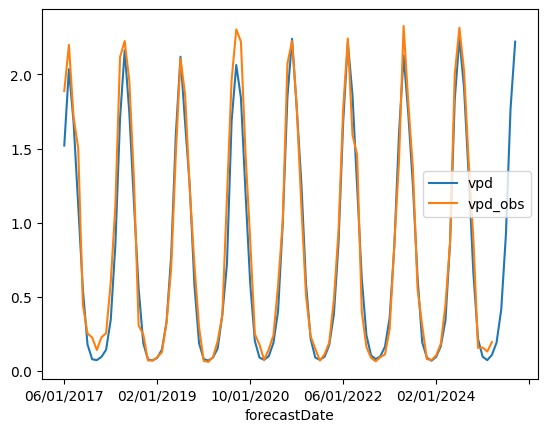

In [73]:
ecmwf[(ecmwf['point'] == 9) & (ecmwf['forecastInterval'] == 5)].plot(x='forecastDate',y=['vpd','vpd_obs'],kind='line')         

In [74]:
final_ML

,Month,Horizon,nMAE_over_std,Best_Model,MAE,por_STD,por_MEAN
0,jan,1,0.664210,ML,0.017342,0.026109,0.063782
1,jan,2,0.619628,ML,0.016178,0.026109,0.063782
2,jan,3,0.429864,ML,0.011223,0.026109,0.063782
3,jan,4,0.750101,SA,0.019585,0.026109,0.063782
4,jan,5,0.566280,ML,0.014785,0.026109,0.063782
...,...,...,...,...,...,...,...
139,dec,8,1.125140,ML,0.064856,0.057642,0.095669
140,dec,9,1.028066,ML,0.059260,0.057642,0.095669
141,dec,10,1.095934,ML,0.063172,0.057642,0.095669
142,dec,11,1.030359,ML,0.059392,0.057642,0.095669


In [66]:
ecmwf[(ecmwf['point'] == 9) & (ecmwf['forecastInterval'] == 0)].head(100)

,point,analysisDate,forecastDate,forecastInterval,t,td,rh,vpd,u,v,pcp,vpd_obs,vpd error,abs vpd error,month
4704,9,01/01/2017,01/01/2017,0,-8.7,-12.0,77.2,0.072,0.0033,0.4591,2.355704e-08,0.072,0.0,0.0,1
4710,9,02/01/2017,02/01/2017,0,-3.9,-7.7,75.2,0.113,0.0495,0.4007,1.334094e-08,0.113,0.0,0.0,2
4716,9,03/01/2017,03/01/2017,0,-0.9,-7.3,61.8,0.218,0.3974,0.4993,1.223527e-08,0.218,0.0,0.0,3
4722,9,04/01/2017,04/01/2017,0,4.8,-4.3,51.6,0.417,0.7636,0.1322,1.796638e-08,0.417,0.0,0.0,4
4728,9,05/01/2017,05/01/2017,0,12.4,-1.3,38.6,0.885,0.6927,0.7421,1.475495e-08,0.885,0.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5262,9,10/01/2024,10/01/2024,0,11.2,-4.6,32.7,0.896,0.3519,0.2376,5.491600e-09,0.896,0.0,0.0,10
5268,9,11/01/2024,11/01/2024,0,-3.4,-8.6,67.5,0.154,-0.0804,0.0224,1.193162e-08,0.154,0.0,0.0,11
5274,9,12/01/2024,12/01/2024,0,-5.3,-11.4,62.2,0.156,-0.1688,0.1207,6.915602e-09,0.156,0.0,0.0,12
5280,9,01/01/2025,01/01/2025,0,-6.7,-12.1,65.2,0.129,-0.0408,0.1659,8.575679e-09,0.129,0.0,0.0,1


In [35]:
gp=ecmwf.groupby(['point','month','forecastInterval'],as_index=False)['abs vpd error'].agg(['mean','std'])
#gpmae=ecmwf.groupby(['point','month','forecastInterval'],as_index=False)[['vpd_obs','vpd']].agg(
#    mae=('vpd_obs', lambda x: (x - ecmwf.loc[x.index, 'vpd']).abs().mean())
#)
gp.rename(columns={'mean':'mean_abs_vpd_error','std':'std_abs_vpd_error'},inplace=True)
gp['mae_over_std']=gp['mean_abs_vpd_error']/gp['std_abs_vpd_error']
print(gp.head())

   point  month  forecastInterval  mean_abs_vpd_error  std_abs_vpd_error  \
0      1      1                 0             0.00000           0.000000   
1      1      1                 1             0.01250           0.011238   
2      1      1                 2             0.01475           0.013156   
3      1      1                 3             0.01425           0.014587   
4      1      1                 4             0.01275           0.016069   

   mae_over_std  
0           NaN  
1      1.112328  
2      1.121190  
3      0.976885  
4      0.793451  


In [36]:
final_model=gp.loc[gp['point']==    9]
month_name={1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
final_model['month']=final_model['month'].map(month_name)
final_model

/tmp/ipykernel_2935/304150684.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_model['month']=final_model['month'].map(month_name)


,point,month,forecastInterval,mean_abs_vpd_error,std_abs_vpd_error,mae_over_std
576,9,jan,0,0.000000,0.000000,NaN
577,9,jan,1,0.018875,0.018091,1.043363
578,9,jan,2,0.020500,0.020990,0.976665
579,9,jan,3,0.020625,0.022652,0.910505
580,9,jan,4,0.019125,0.024222,0.789577
...,...,...,...,...,...,...
643,9,dec,1,0.050250,0.031222,1.609465
644,9,dec,2,0.043250,0.043765,0.988237
645,9,dec,3,0.045625,0.048134,0.947883
646,9,dec,4,0.047500,0.049762,0.954538


## FULL Analysis 

In [37]:
all_results

[{'regime': 'jan',
  'months': [1],
  'por_STD': np.float64(0.026109367601919932),
  'por_MEAN': np.float64(0.06378236175115203),
  'mean_MAE': np.float32(0.016855031),
  'mean_MAE_over_mean': np.float64(0.2642585001425244),
  'mean_MAE_over_std': np.float64(0.6455549406209259),
  'quant_MAE': np.float32(0.035990313),
  'quant_MAE_over_mean': np.float64(0.5642674825356899),
  'quant_MAE_over_std': np.float64(1.3784444435512377),
  'mean_Rank': np.float64(0.16820670214734276),
  'quant_Rank': np.float64(0.1168576746008424),
  'mean_ExtremeBias': np.float32(-0.05537374),
  'quant_ExtremeBias': np.float32(-0.02945679),
  'horizon_stats': {1: {'mae_mean': 0.0173420961946249,
    'nmastd_mean': 0.6642097882068382,
    'nmamn_mean': 0.27189487891254654,
    'mae_quant': 0.0408928357064724,
    'nmastd_quant': 1.5662132225613166,
    'nmamn_quant': 0.6411308024369677,
    'n_samples': 7},
   2: {'mae_mean': 0.01617809757590294,
    'nmastd_mean': 0.6196281306745227,
    'nmamn_mean': 0.253645

In [38]:
final=[]
for mon in all_results:
    for h in mon['horizon_stats']:
    #    print(h)
    #    print(mon['regime'],h,mon['horizon_stats'][h]['nmastd_mean'],mon['horizon_stats'][h]['nmastd_quant'],mon['sarima_results']['mae_over_std'])
        if mon['horizon_stats'][h]['nmastd_mean'] <= mon['horizon_stats'][h]['nmastd_quant']:
           mlV= mon['horizon_stats'][h]['nmastd_mean'] 
           mae= mon['horizon_stats'][h]['mae_mean']
           
           mlT = "MM"
        else:
           mlV= mon['horizon_stats'][h]['nmastd_quant'] 
           mlT = "QT"
           mae= mon['horizon_stats'][h]['mae_quant']


        if mon['sarima_results']['mae_over_std'] < mlV*.85:
           val= mon['sarima_results']['mae_over_std']
           model="SA"
           mae = mon['sarima_results']['mae']
        else:
           val= mlV
           model='ML'

        std=mon['por_STD']
        mn=mon['por_MEAN']
        print(f"{mon['regime']},{h},{val:.3f},{model}")
        tmp={
           "Month":mon['regime'],  
           "Horizon":h,
           "nMAE_over_std":float(val),
           "Best_Model":model,
           "MAE": mae,
           "por_STD":std,
           "por_MEAN":mn
        }
        final.append(tmp)

final_ML=pd.DataFrame(final)



jan,1,0.664,ML
jan,2,0.620,ML
jan,3,0.430,ML
jan,4,0.750,SA
jan,5,0.566,ML
jan,6,0.628,ML
jan,7,0.618,ML
jan,8,0.707,ML
jan,9,0.834,ML
jan,10,0.732,ML
jan,11,0.424,ML
jan,12,0.550,ML
feb,1,0.542,ML
feb,2,0.528,ML
feb,3,0.515,ML
feb,4,0.379,ML
feb,5,0.455,ML
feb,6,0.450,ML
feb,7,0.494,ML
feb,8,0.474,ML
feb,9,0.567,ML
feb,10,0.564,ML
feb,11,0.403,ML
feb,12,0.341,ML
mar,1,0.758,ML
mar,2,0.858,ML
mar,3,0.993,ML
mar,4,0.826,ML
mar,5,0.807,ML
mar,6,1.084,ML
mar,7,0.852,ML
mar,8,0.887,ML
mar,9,0.793,ML
mar,10,0.720,ML
mar,11,0.561,ML
mar,12,0.653,ML
apr,1,0.775,ML
apr,2,0.799,ML
apr,3,0.717,ML
apr,4,0.715,ML
apr,5,0.782,ML
apr,6,0.787,ML
apr,7,0.808,ML
apr,8,0.752,SA
apr,9,0.774,ML
apr,10,0.752,SA
apr,11,0.752,SA
apr,12,0.752,SA
may,1,0.634,ML
may,2,0.730,ML
may,3,0.569,ML
may,4,0.678,ML
may,5,0.647,ML
may,6,0.562,ML
may,7,0.613,ML
may,8,0.638,ML
may,9,0.679,ML
may,10,0.643,ML
may,11,0.766,ML
may,12,0.821,ML
jun,1,0.908,ML
jun,2,0.753,ML
jun,3,0.826,ML
jun,4,0.768,ML
jun,5,0.906,ML
jun,6,0.86

In [39]:
final_model.columns
for col in final_model.columns:
    final_model.rename(columns={col:f"model_{col}"},inplace=True)

/tmp/ipykernel_2935/559050783.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_model.rename(columns={col:f"model_{col}"},inplace=True)


In [40]:
final_model.rename(columns={"model_month":"Month","model_forecastInterval":"Horizon"},inplace=True)

/tmp/ipykernel_2935/800201801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_model.rename(columns={"model_month":"Month","model_forecastInterval":"Horizon"},inplace=True)


In [41]:
final_model.columns

Index(['model_point', 'Month', 'Horizon', 'model_mean_abs_vpd_error',
       'model_std_abs_vpd_error', 'model_mae_over_std'],
      dtype='object')

In [75]:
merged = pd.merge(
    final_ML,
    final_model,
    on=['Month', 'Horizon'],
    how='left'
)

In [76]:
merged.columns

Index(['Month', 'Horizon', 'nMAE_over_std', 'Best_Model', 'MAE', 'por_STD',
       'por_MEAN', 'model_point', 'model_mean_abs_vpd_error',
       'model_std_abs_vpd_error', 'model_mae_over_std'],
      dtype='object')

In [77]:

def compare_models(row):
    ml_mae_norm = row['nMAE_over_std']
    pr_mae_norm = row['model_mae_over_std']
    ml_mod = row['Best_Model']
    hr = row['Horizon']
    if hr < 6:
        if pr_mae_norm < ml_mae_norm :
            row['Final Norm'] = pr_mae_norm
            row['Final Model'] = 'PR'
        else:
            row['Final Norm'] = ml_mae_norm
            row['Final Model'] = ml_mod
    else:
        row['Final Norm'] = ml_mae_norm
        row['Final Model'] = ml_mod
    return row
merged = merged.apply(compare_models, axis=1)

In [78]:
merged.head()

,Month,Horizon,nMAE_over_std,Best_Model,MAE,por_STD,por_MEAN,model_point,model_mean_abs_vpd_error,model_std_abs_vpd_error,model_mae_over_std,Final Norm,Final Model
0,jan,1,0.664210,ML,0.017342,0.026109,0.063782,9.0,0.018875,0.018091,1.043363,0.664210,ML
1,jan,2,0.619628,ML,0.016178,0.026109,0.063782,9.0,0.020500,0.020990,0.976665,0.619628,ML
2,jan,3,0.429864,ML,0.011223,0.026109,0.063782,9.0,0.020625,0.022652,0.910505,0.429864,ML
3,jan,4,0.750101,SA,0.019585,0.026109,0.063782,9.0,0.019125,0.024222,0.789577,0.750101,SA
4,jan,5,0.566280,ML,0.014785,0.026109,0.063782,9.0,0.020375,0.026801,0.760246,0.566280,ML


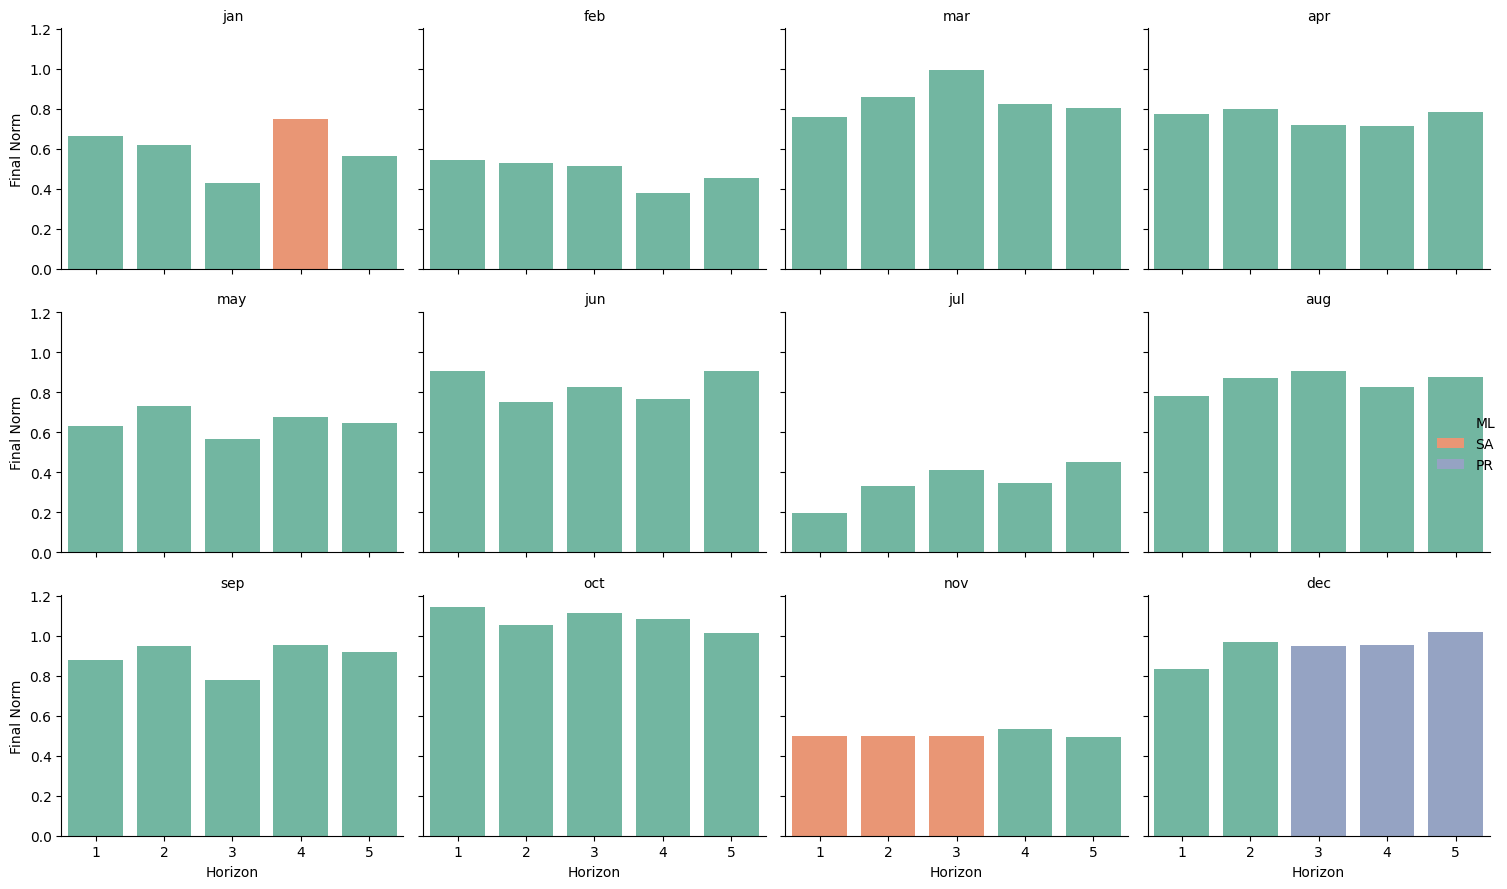

Final Model
ML    53
SA     4
PR     3
Name: count, dtype: int64

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
finalDf=merged.loc[merged['Horizon'] < 6]
# Create a FacetGrid with one column per month
g = sns.FacetGrid(
    finalDf,
    col="Month",
    col_wrap=4,  # 4 plots per row
    height=3,
    aspect=1.2
)

# Map a barplot to each facet
g.map_dataframe(
    sns.barplot,
    x="Horizon",
    y="Final Norm",
    hue="Final Model",
    hue_order=['ML', 'SA', 'PR'],  # Explicitly set all categories
    palette="Set2"
)

# Add legend and labels
g.add_legend()
g.set_axis_labels("Horizon", "Final Norm")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

finalDf['Final Model'].value_counts()

In [49]:
ecmwf.head()

,point,analysisDate,forecastDate,forecastInterval,t,td,rh,vpd,u,v,pcp,vpd_obs,vpd error,abs vpd error,month
0,1,01/01/2017,01/01/2017,0,-10.8,-13.7,78.9,0.057,1.2499,0.9278,1.748798e-08,0.057,0.000,0.000,1
1,1,01/01/2017,02/01/2017,1,-8.1,-11.6,76.0,0.079,1.4632,0.6690,1.000410e-08,0.085,0.006,0.006,2
2,1,01/01/2017,03/01/2017,2,-3.7,-8.2,71.1,0.134,1.4747,0.5108,1.393254e-08,0.155,0.021,0.021,3
3,1,01/01/2017,04/01/2017,3,2.1,-4.9,59.8,0.285,1.8091,0.4843,1.679983e-08,0.350,0.065,0.065,4
4,1,01/01/2017,05/01/2017,4,9.7,-0.9,47.6,0.628,1.6640,0.4686,1.745140e-08,0.777,0.149,0.149,5


In [82]:
ecmwf_means=ecmwf.groupby(['month','forecastInterval'],as_index=False)[['vpd','vpd_obs','abs vpd error']].agg(['mean','std'])

In [83]:
ecmwf_means

month forecastInterval       vpd             vpd_obs            \
                               mean       std      mean       std   
0      1                0  0.169867  0.083920  0.169867  0.083920   
1      1                1  0.169341  0.079847  0.169781  0.083700   
2      1                2  0.165644  0.075859  0.169781  0.083700   
3      1                3  0.156916  0.071409  0.169781  0.083700   
4      1                4  0.154134  0.067762  0.169781  0.083700   
..   ...              ...       ...       ...       ...       ...   
67    12                1  0.186628  0.077959  0.214884  0.105125   
68    12                2  0.172119  0.074662  0.214884  0.105125   
69    12                3  0.170256  0.073633  0.214884  0.105125   
70    12                4  0.164703  0.071252  0.214884  0.105125   
71    12                5  0.167456  0.074747  0.214884  0.105125   

   abs vpd error            
            mean       std  
0       0.000000  0.000000  
1       0.029984  0.029584  
2       0.026206  0.025510  
3       0.029303  0.032679  
4       0.030097  0.030289  
..           ...       ...  
67      0.041863  0.041100  
68      0.047522  0.045710  
69      0.049428  0.046679  
70      0.052669  0.045685  
71      0.050622  0.047539  

[72 rows x 8 columns]

In [84]:
ecmwf_means.columns=['_'.join(map(str, col)).strip('_') for col in ecmwf_means.columns.values]

In [85]:
ecmwf_means.head()

,month,forecastInterval,vpd_mean,vpd_std,vpd_obs_mean,vpd_obs_std,abs vpd error_mean,abs vpd error_std
0,1,0,0.169867,0.083920,0.169867,0.08392,0.000000,0.000000
1,1,1,0.169341,0.079847,0.169781,0.08370,0.029984,0.029584
2,1,2,0.165644,0.075859,0.169781,0.08370,0.026206,0.025510
3,1,3,0.156916,0.071409,0.169781,0.08370,0.029303,0.032679
4,1,4,0.154134,0.067762,0.169781,0.08370,0.030097,0.030289


In [86]:
ecmwf_means[['month','forecastInterval','abs vpd error_mean']]

,month,forecastInterval,abs vpd error_mean
0,1,0,0.000000
1,1,1,0.029984
2,1,2,0.026206
3,1,3,0.029303
4,1,4,0.030097
...,...,...,...
67,12,1,0.041863
68,12,2,0.047522
69,12,3,0.049428
70,12,4,0.052669


In [104]:
#aML = final_ML.loc[final_ML['Horizon'] <6]
aML = final_ML.copy()

In [119]:
aML.rename(columns={ 'nMAE_over_std':'ML_MAE_over_std', 'Best_Model':'ML_Best_Model', 'MAE':'ML_MAE', 'por_STD':'ML_por_STD',
       'por_MEAN':'ML_por_MEAN'},inplace=True)

In [120]:
aML.columns

Index(['Month', 'Horizon', 'ML_MAE_over_std', 'ML_Best_Model', 'ML_MAE',
       'ML_por_STD', 'ML_por_MEAN'],
      dtype='object')

In [88]:
aML.shape

(60, 7)

In [89]:
ecmwf_means= ecmwf_means.loc[ecmwf_means['forecastInterval'] > 0]

In [90]:
ecmwf_means.rename(columns={'month':'Month','forecastInterval':'Horizon','abs vpd error_mean':'ECMWF_Mean_Abs_VPD_Error'},inplace=True)

/tmp/ipykernel_2935/945796715.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecmwf_means.rename(columns={'month':'Month','forecastInterval':'Horizon','abs vpd error_mean':'ECMWF_Mean_Abs_VPD_Error'},inplace=True)


In [91]:
month_name={1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
ecmwf_means['Month']=ecmwf_means['Month'].map(month_name)

/tmp/ipykernel_2935/3359545807.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecmwf_means['Month']=ecmwf_means['Month'].map(month_name)


In [121]:
all_means=pd.merge(aML,ecmwf_means,on=['Month','Horizon'],how='left')

Text(0.5, 1.0, 'MAE Comparison at Horizon 1')

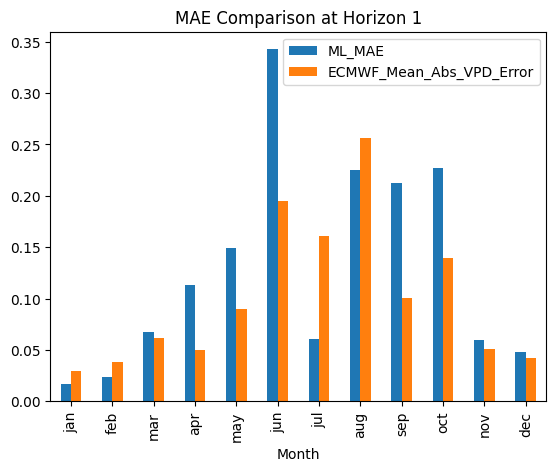

In [142]:
all_means.loc[all_means['Horizon'] == 1].plot(x='Month', y=['ML_MAE','ECMWF_Mean_Abs_VPD_Error'], kind='bar')
plt.title("MAE Comparison at Horizon 1")

In [124]:
all_means['ML_norm_mae'] = all_means['ML_MAE']/all_means['ML_por_STD']
all_means['ECMWF_norm_mae'] = all_means['ECMWF_Mean_Abs_VPD_Error']/all_means['vpd_obs_std']                    

In [125]:
all_means[all_means['Horizon'] == 5].plot(x='Month', y=['ML_por_STD','ML_vpd_obs_std'], kind='bar')

KeyError: "['ML_vpd_obs_std'] not in index"

<Axes: xlabel='Month'>

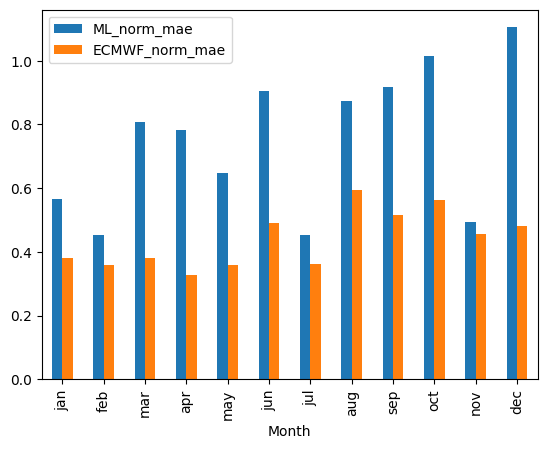

In [115]:
all_means.loc[all_means['Horizon'] == 5].plot(x='Month', y=['ML_norm_mae','ECMWF_norm_mae'], kind='bar')


<Axes: xlabel='Month'>

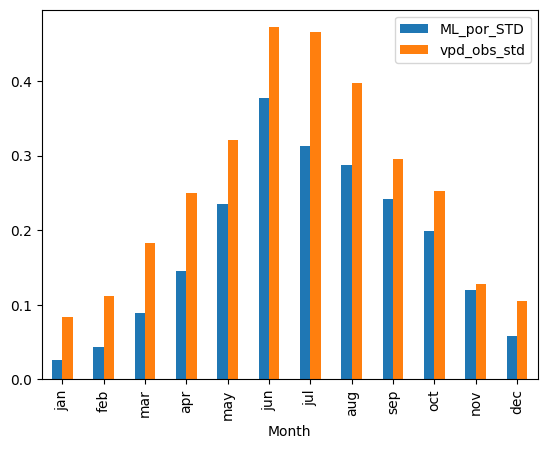

In [127]:
all_means.loc[all_means['Horizon'] == 5].plot(x='Month', y=['ML_por_STD','vpd_obs_std'], kind='bar')


In [136]:
all_means['ML_norm_mae_mean'] = all_means['ML_MAE']/all_means['ML_por_MEAN']
all_means['ECMWF_norm_mae_mean'] = all_means['ECMWF_Mean_Abs_VPD_Error']/all_means['vpd_obs_mean']

In [139]:

def compare_models(row,mlCol,modelCol):
    ml_mae_norm = row[mlCol]
    pr_mae_norm = row[modelCol]
    ml_mod = row['ML_Best_Model']
    hr = row['Horizon']
    if hr < 6:
        if pr_mae_norm < ml_mae_norm :
            row['Final Norm'] = pr_mae_norm
            row['Final Model'] = 'PR'
        else:
            row['Final Norm'] = ml_mae_norm
            row['Final Model'] = ml_mod
    else:
        row['Final Norm'] = ml_mae_norm
        row['Final Model'] = ml_mod
    return row
finalDf = all_means.apply(compare_models, axis=1,args=('ML_MAE', 'ECMWF_Mean_Abs_VPD_Error'))
#finalDf = all_means.apply(compare_models, axis=1,args=('ML_norm_mae_mean', 'ECMWF_norm_mae_mean'))


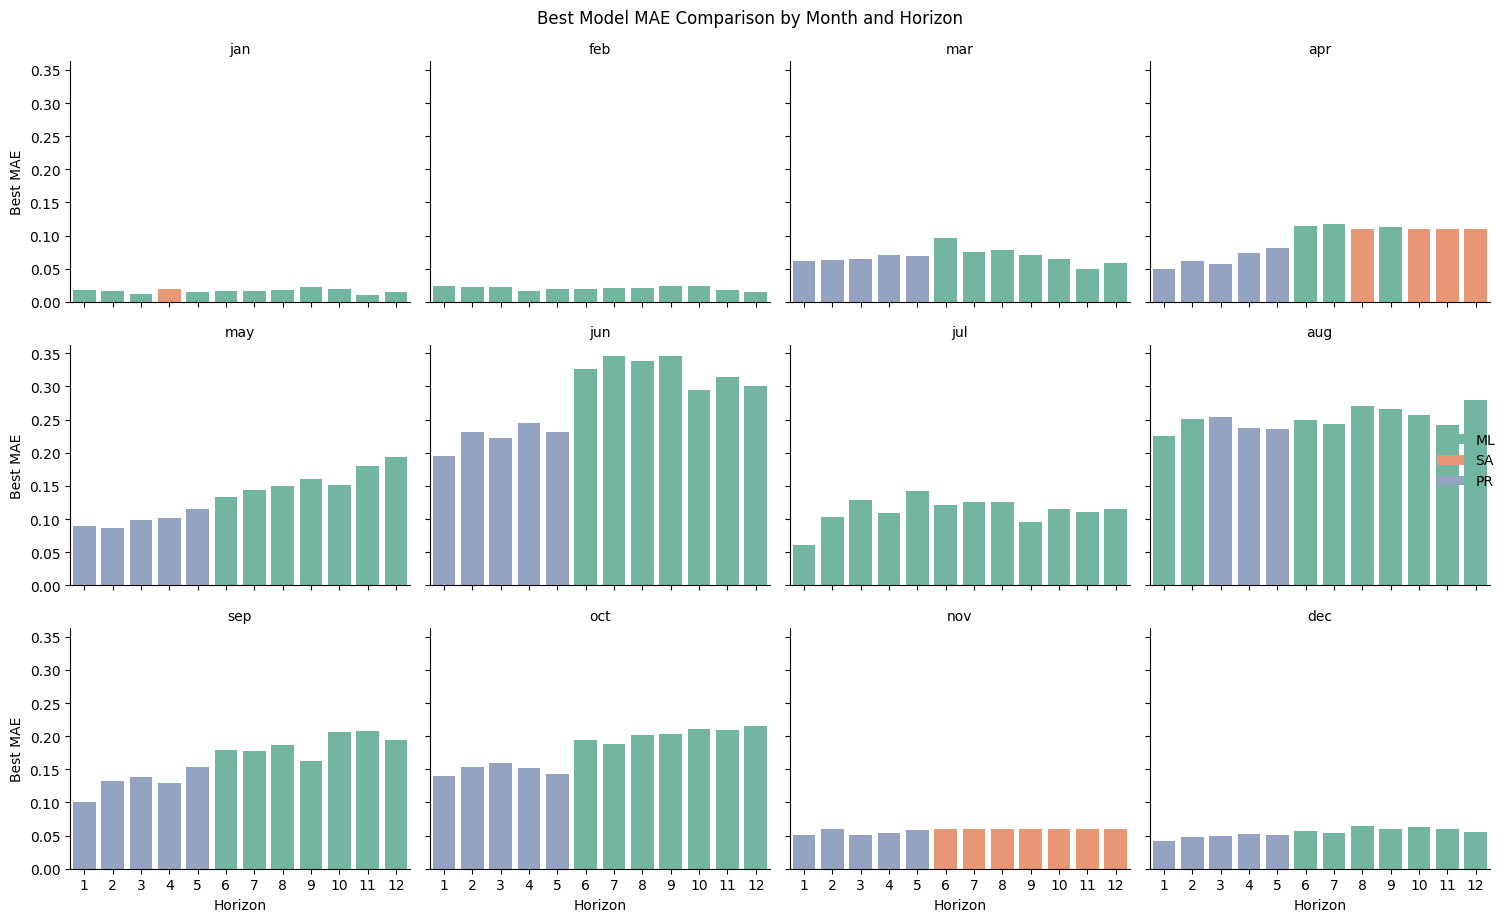

Final Model
ML    89
PR    43
SA    12
Name: count, dtype: int64

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
#finalDf=all_means.loc[all_means['Horizon'] < 6]

# Create a FacetGrid with one column per month
g = sns.FacetGrid(
    finalDf,
    col="Month",
    col_wrap=4,  # 4 plots per row
    height=3,
    aspect=1.2
)

# Map a barplot to each facet
g.map_dataframe(
    sns.barplot,
    x="Horizon",
    y="Final Norm",
    hue="Final Model",
    hue_order=['ML', 'SA', 'PR'],  # Explicitly set all categories
    palette="Set2"
)

# Add legend and labels
g.add_legend()
g.set_axis_labels("Horizon", "Best MAE")
g.set_titles("{col_name}")
plt.tight_layout()
plt.suptitle("Best Model MAE Comparison by Month and Horizon", y=1.02)
plt.show()

finalDf['Final Model'].value_counts()

In [103]:
all_means['Horizon'].value_counts()

Horizon
1    12
2    12
3    12
4    12
5    12
Name: count, dtype: int64

## Stop Here

In [ ]:
gp=ecmwf.groupby(['point','month','forecastInterval'],as_index=False)[['vpd','abs vpd error']].agg(['mean','std'])


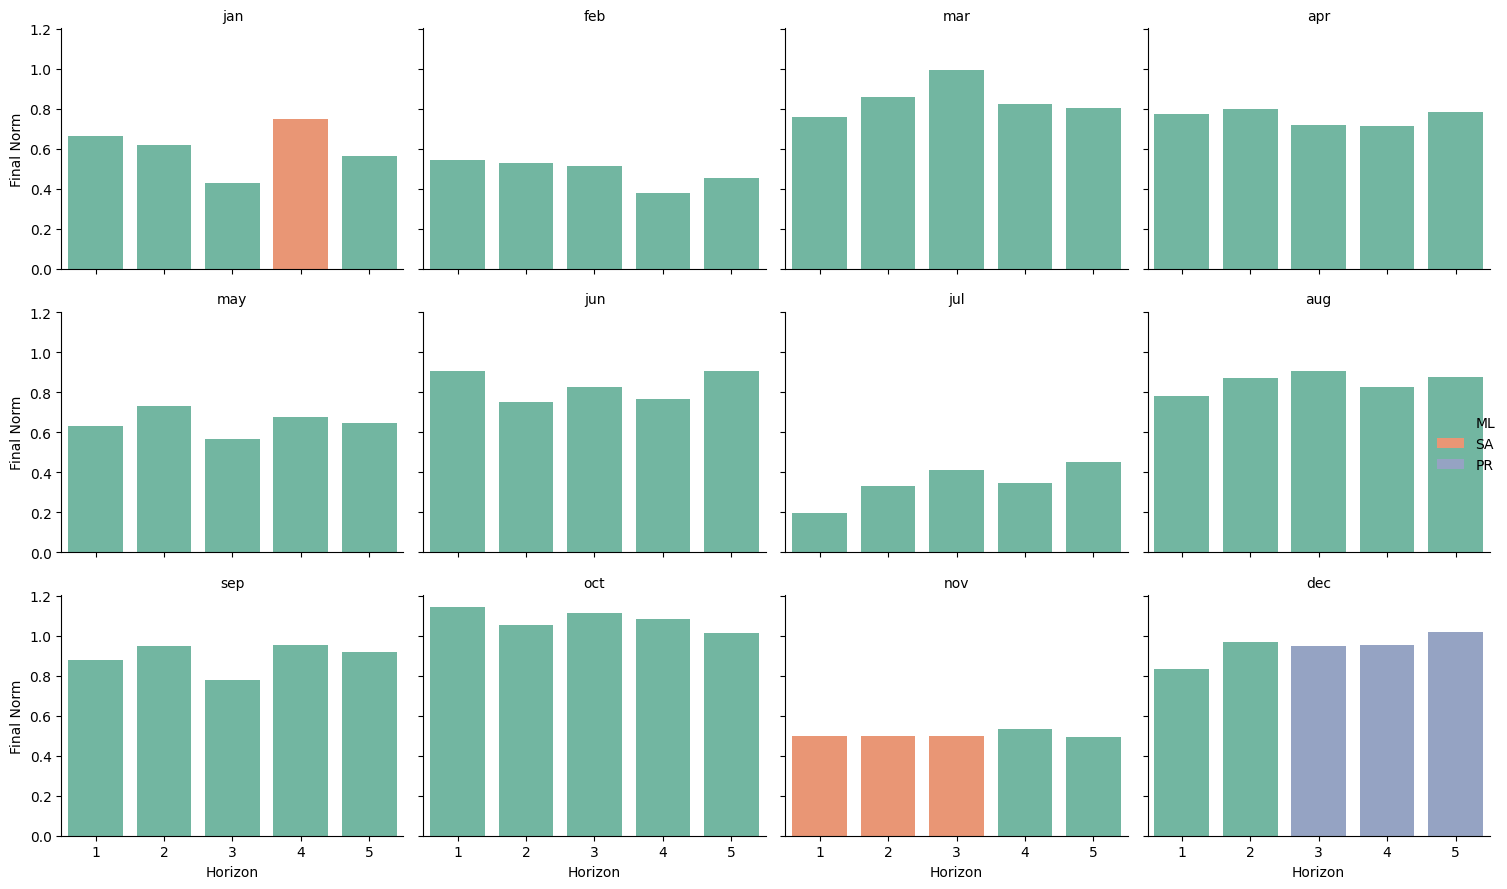

Final Model
ML    53
SA     4
PR     3
Name: count, dtype: int64

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
finalDf=merged.loc[merged['Horizon'] < 6]
# Create a FacetGrid with one column per month
g = sns.FacetGrid(
    finalDf,
    col="Month",
    col_wrap=4,  # 4 plots per row
    height=3,
    aspect=1.2
)

# Map a barplot to each facet
g.map_dataframe(
    sns.barplot,
    x="Horizon",
    y="Final Norm",
    hue="Final Model",
    hue_order=['ML', 'SA', 'PR'],  # Explicitly set all categories
    palette="Set2"
)

# Add legend and labels
g.add_legend()
g.set_axis_labels("Horizon", "Final Norm")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

finalDf['Final Model'].value_counts()

In [49]:
finalDf

,Month,Horizon,nMAE_over_std,Best_Model
0,jan,1,0.594298,ML
1,jan,2,0.533154,ML
2,jan,3,0.595251,ML
3,jan,4,0.735486,ML
4,jan,5,0.869348,ML
...,...,...,...,...
139,dec,8,1.149250,ML
140,dec,9,1.109563,ML
141,dec,10,0.937156,ML
142,dec,11,0.896364,ML


##  Stop Here -----------------

In [136]:
ecmwf_means

NameError: name 'ecmwf_means' is not defined

In [38]:
dv = all_delta_vpd
ar = all_abs_resid

# Define bands by rounding ΔVPD (adjust decimals if needed)
dv_band = np.round(dv, 3)

bands = np.unique(dv_band)

rows = []
for b in bands:
    mask = dv_band == b
    rows.append({
        "ΔVPD": b,
        "n": mask.sum(),
        "mean_abs_resid": np.mean(ar[mask]),
        "median_abs_resid": np.median(ar[mask])
    })

# Sort by ΔVPD
rows = sorted(rows, key=lambda x: x["ΔVPD"])

# Print table
print(f"{'ΔVPD':>8} {'n':>4} {'mean|resid|':>12} {'median|resid|':>14}")
for r in rows:
    print(
        f"{r['ΔVPD']:8.3f} "
        f"{r['n']:4d} "
        f"{r['mean_abs_resid']:12.3f} "
        f"{r['median_abs_resid']:14.3f}"
    )

    ΔVPD    n  mean|resid|  median|resid|
  -0.898   11        0.425          0.440
  -0.449   24        0.262          0.154
   0.412   12        0.106          0.073
   0.523   12        0.240          0.249
   0.528   12        0.502          0.494


## Evaluation OLD

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


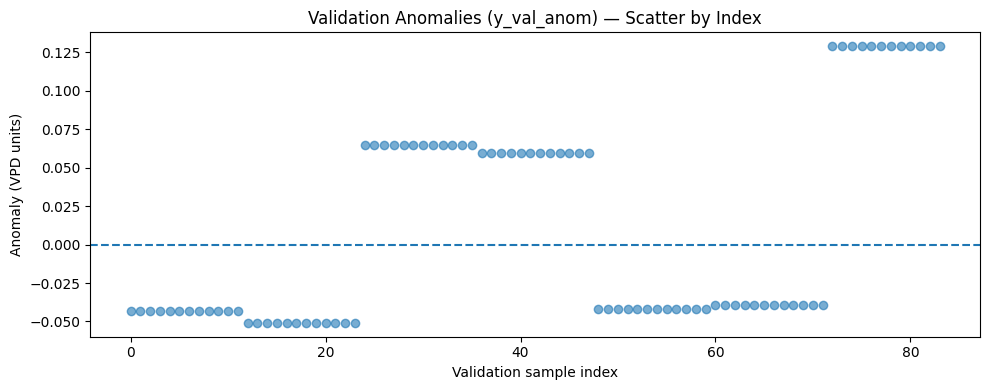


MAE by Horizon (Mean vs Quantile):



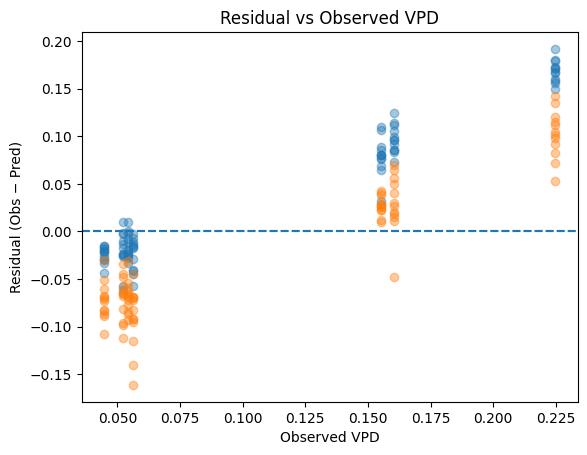

In [ ]:


# ============================================================
# Predict (two-headed model)
# ============================================================
# =========================
# MODEL PREDICTION
# =========================

y_mean_pred, y_quantile_pred = model.predict(X_val)

y_mean_pred = y_mean_pred.reshape(-1)
y_quantile_pred = y_quantile_pred.reshape(-1)


# ============================================================
# Inverse-scale anomalies
# ============================================================
y_val_anom = y_scaler.inverse_transform(
    y_val.reshape(-1, 1)
).ravel()

y_mean_pred_anom = y_scaler.inverse_transform(
    y_mean_pred.reshape(-1, 1)
).ravel()

y_quantile_pred_anom = y_scaler.inverse_transform(
    y_quantile_pred.reshape(-1, 1)
).ravel()

plt.figure(figsize=(10,4))
plt.plot(y_val_anom, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Validation Anomalies (y_val_anom) — Scatter by Index")
plt.ylabel("Anomaly (VPD units)")
plt.xlabel("Validation sample index")
plt.tight_layout()
plt.show()

# ============================================================
# Add monthly means back (physical VPD)
# ============================================================
monthly_mean_dict = monthly_mean.to_dict()

y_val_phys = np.array([
    y_val_anom[i] + monthly_mean_dict[meta_month_val[i]]
    for i in range(len(y_val_anom))
])

y_mean_pred_phys = np.array([
    y_mean_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
    for i in range(len(y_mean_pred_anom))
])

y_quantile_pred_phys = np.array([
    y_quantile_pred_anom[i] + monthly_mean_dict[meta_month_val[i]]
    for i in range(len(y_quantile_pred_anom))
])


# ============================================================
# Helper: full evaluation
# ============================================================
def evaluate_head(name, y_pred_phys, regime_months):
    errors = y_val_phys - y_pred_phys
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt(np.mean(errors ** 2))
    
    plt.scatter(y_val_phys, errors, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Observed VPD")
    plt.ylabel("Residual (Obs − Pred)")
    plt.title("Residual vs Observed VPD")



    # print(regime_months.dtype)
    # print(type(regime_months[0]), regime_months[0])

 #   regime_mask = np.isin( np.array(regime_months),meta_month_val)
    regime_mask = np.zeros_like(meta_month_val, dtype=bool)
    for m in REGIME_MONTHS:
        regime_mask |= (meta_month_val == m)



    regime_mae = abs_errors[regime_mask].mean() if regime_mask.any() else np.nan

    rank_corr = np.nan
    if regime_mask.sum() > 2:
        obs = y_val_phys[regime_mask]
        pred = y_pred_phys[regime_mask]
        obs_rank = np.argsort(np.argsort(obs))
        pred_rank = np.argsort(np.argsort(pred))
        rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

    q90 = np.percentile(y_val_phys, 90)
    extreme_mask = y_val_phys >= q90
    extreme_bias = (
        np.mean(y_pred_phys[extreme_mask] - y_val_phys[extreme_mask])
        if extreme_mask.any() else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Regime_MAE": regime_mae,
        "Regime_Rank": rank_corr,
        "Extreme_Bias": extreme_bias
    }


# ============================================================
# Run evaluation
# ============================================================
mean_metrics = evaluate_head("MEAN", y_mean_pred_phys, REGIME_MONTHS)
quantile_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys, REGIME_MONTHS)

# ============================================================
# SIDE-BY-SIDE SUMMARY
# ============================================================
fout=open(f"{REGIME_NAME}_delta_vpd_resid.txt","w")

fout.write(f"\n================ {REGIME_NAME.upper()} TWO-HEAD COMPARISON =================\n")
fout.write(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}\n")
fout.write("-" * 50 + "\n")

for key in mean_metrics:
    fout.write(
        f"{key:<20} "
        f"{mean_metrics[key]:>12.3f} "
        f"{quantile_metrics[key]:>15.3f}\n"
    )

# ============================================================
# MAE BY HORIZON (OPTIONAL BUT IDENTICAL)
# ============================================================
print(f"\nMAE by Horizon (Mean vs Quantile):\n")
# Containers for pooled August diagnostics
all_delta_vpd = []
all_abs_resid = []
all_horizon = []
for h in sorted(np.unique(meta_horizon_val)):
    mask = meta_horizon_val == h

    # --- existing metrics (unchanged) ---
    resid_mean = y_val_phys[mask] - y_mean_pred_phys[mask]
    resid_quant = y_val_phys[mask] - y_quantile_pred_phys[mask]

    mae_mean = np.abs(resid_mean).mean()
    mae_quant = np.abs(resid_quant).mean()

    fout.write(
        f"  h={h:2d} → Mean={mae_mean:.3f} | Quantile={mae_quant:.3f}\n"
    )

    # --- NEW: ΔVPD diagnostics (mean head only is enough) ---
    y_obs = y_val_phys[mask]

    # IMPORTANT: ensure time order inside horizon
    # If you have target timestamps, uncomment and use:
    # order = np.argsort(meta_target_time_val[mask])
    # y_obs = y_obs[order]
    # resid_mean = resid_mean[order]

    # Compute ΔVPD safely within this horizon
    delta_vpd = np.empty_like(y_obs)
    delta_vpd[0] = np.nan
    delta_vpd[1:] = y_obs[1:] - y_obs[:-1]

    valid = ~np.isnan(delta_vpd)

    # Pool for later analysis
    all_delta_vpd.append(delta_vpd[valid])
    all_abs_resid.append(np.abs(resid_mean[valid]))
    all_horizon.append(np.full(np.sum(valid), h))



corr = np.corrcoef(all_delta_vpd, all_abs_resid)[0,1]
fout.write(f"Corr(|residual|, ΔVPD) = {corr}\n")

fout.close()

In [23]:
regime_mask = np.zeros_like(meta_month_val, dtype=bool)
for m in REGIME_MONTHS:
    regime_mask |= (meta_month_val == m)

print(regime_mask)


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T

In [10]:
def evaluate_head(name, y_pred_phys):
    errors = y_val_phys - y_pred_phys
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt(np.mean(errors ** 2))

    # July diagnostics
    july_mask = meta_month_val == 7
    july_mae = abs_errors[july_mask].mean()

    rank_corr = np.nan
    if july_mask.sum() > 2:
        obs = y_val_phys[july_mask]
        pred = y_pred_phys[july_mask]
        obs_rank = np.argsort(np.argsort(obs))
        pred_rank = np.argsort(np.argsort(pred))
        rank_corr = np.corrcoef(obs_rank, pred_rank)[0, 1]

    # Extreme bias
    q90 = np.percentile(y_val_phys, 90)
    extreme_mask = y_val_phys >= q90
    extreme_bias = np.mean(
        y_pred_phys[extreme_mask] - y_val_phys[extreme_mask]
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "July_MAE": july_mae,
        "July_Rank": rank_corr,
        "Extreme_Bias": extreme_bias
    }


In [11]:
mean_metrics = evaluate_head("MEAN", y_mean_pred_phys)
quant_metrics = evaluate_head("QUANTILE", y_quantile_pred_phys)

print("\n================ TWO-HEAD COMPARISON =================")
print(f"{'Metric':<20} {'Mean Head':>12} {'Quantile Head':>15}")
print("-" * 50)

for k in mean_metrics:
    print(f"{k:<20} {mean_metrics[k]:>12.3f} {quant_metrics[k]:>15.3f}")



================ TWO-HEAD COMPARISON =================
Metric                  Mean Head   Quantile Head
--------------------------------------------------
MAE                         0.224           0.094
RMSE                        0.246           0.117
July_MAE                    0.224           0.094
July_Rank                  -0.061           0.212
Extreme_Bias               -0.298           0.023


## Ensemble

In [7]:
def evaluate_head(
    y_true_phys: np.ndarray,
    y_pred_phys: np.ndarray,
    meta_month_val: np.ndarray,
    meta_horizon_val: np.ndarray,
    *,
    focus_month: int | None = 7,
    enable_extreme_gate: bool = True,
    extreme_percentile: float = 90.0,
) -> dict:
    """
    Evaluate predictions in physical units.

    Args:
      y_true_phys, y_pred_phys: arrays shape (N,)
      meta_month_val, meta_horizon_val: arrays shape (N,)
      focus_month: month for month-specific diagnostics (None disables)
      enable_extreme_gate: on/off for extreme diagnostics
      extreme_percentile: percentile threshold computed on y_true_phys (global)

    Returns:
      dict of metrics comparable to earlier evaluation.
    """
    y_true_phys = np.asarray(y_true_phys).reshape(-1)
    y_pred_phys = np.asarray(y_pred_phys).reshape(-1)

    if y_true_phys.shape != y_pred_phys.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true_phys.shape} vs y_pred {y_pred_phys.shape}")

    errors = y_true_phys - y_pred_phys
    abs_errors = np.abs(errors)

    mae = float(abs_errors.mean())
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    # Month diagnostics (default July)
    month_mae = np.nan
    rank_corr = np.nan
    if focus_month is not None:
        m_mask = (meta_month_val == focus_month)
        if m_mask.any():
            month_mae = float(abs_errors[m_mask].mean())
            if m_mask.sum() > 2:
                obs = y_true_phys[m_mask]
                pred = y_pred_phys[m_mask]
                obs_rank = np.argsort(np.argsort(obs))
                pred_rank = np.argsort(np.argsort(pred))
                rank_corr = float(np.corrcoef(obs_rank, pred_rank)[0, 1])

    # Extreme diagnostics gate
    extreme_bias = np.nan
    if enable_extreme_gate:
        thr = np.percentile(y_true_phys, extreme_percentile)
        extreme_mask = y_true_phys >= thr
        if extreme_mask.any():
            extreme_bias = float(np.mean(y_pred_phys[extreme_mask] - y_true_phys[extreme_mask]))

    return {
        "MAE": mae,
        "RMSE": rmse,
        f"{'July' if focus_month==7 else 'Month'}_MAE": month_mae,
        f"{'July' if focus_month==7 else 'Month'}_Rank": rank_corr,
        "Extreme_Bias": extreme_bias,
    }

In [9]:
N_ENSEMBLE = 10
ensemble_results = []
monthly_mean_dict = monthly_mean.to_dict()
for k in range(N_ENSEMBLE):
    tf.keras.backend.clear_session()
    tf.random.set_seed(100 + k)
    np.random.seed(100 + k)
    print("ENSEMBLE MEMBER", k)
    model = build_two_head_nn(X_train.shape[1])
    model.fit(
        X_train,
        {"mean": y_train, "quantile": y_train},
        validation_data=(X_val, {"mean": y_val, "quantile": y_val}),
        epochs=20,
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
        verbose=0
    )

    pred_mean, pred_quantile = model.predict(X_val)

    pred_mean = pred_mean.ravel()
    pred_quantile = pred_quantile.ravel()

    mean_anom = y_scaler.inverse_transform(pred_mean[:, None]).ravel()
    quant_anom = y_scaler.inverse_transform(pred_quantile[:, None]).ravel()
    y_obs_anom = y_scaler.inverse_transform(y_val[:, None]).ravel()

    mean_phys = np.array([
        mean_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(mean_anom))
    ])

    quant_phys = np.array([
        quant_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(quant_anom))
    ])

    obs_phys = np.array([
        y_obs_anom[i] + monthly_mean_dict[meta_month_val[i]]
        for i in range(len(y_obs_anom))
    ])

    mean_metrics = evaluate_head(
        obs_phys, mean_phys,
        meta_month_val, meta_horizon_val,
        focus_month=7,
        enable_extreme_gate=True,
        extreme_percentile=90
    )

    quant_metrics = evaluate_head(
        obs_phys, quant_phys,
        meta_month_val, meta_horizon_val,
        focus_month=7,
        enable_extreme_gate=True,
        extreme_percentile=90
    )

    ensemble_results.append({"member": k, "head": "mean", **mean_metrics})
    ensemble_results.append({"member": k, "head": "quantile", **quant_metrics})


ENSEMBLE MEMBER 0


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7b37c03efba0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
ENSEMBLE MEMBER 1
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
ENSEMBLE MEMBER 2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
ENSEMBLE MEMBER 3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
ENSEMBLE MEMBER 4
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
ENSEMBLE MEMBER 5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
ENSEMBLE MEMBER 6
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
ENSEMBLE MEMBER 7
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
ENSEMBLE MEMBER 8
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
ENSEMBLE MEMBER 9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


In [10]:
ensemble_results

[{'member': 0,
  'head': 'mean',
  'MAE': 0.2383691966533661,
  'RMSE': 0.26047393679618835,
  'July_MAE': 0.2383691966533661,
  'July_Rank': -0.05879266193694638,
  'Extreme_Bias': -0.27917206287384033},
 {'member': 0,
  'head': 'quantile',
  'MAE': 0.09259501844644547,
  'RMSE': 0.11436363309621811,
  'July_MAE': 0.09259501844644547,
  'July_Rank': 0.11821502036018638,
  'Extreme_Bias': 0.03323899582028389},
 {'member': 1,
  'head': 'mean',
  'MAE': 0.23609007894992828,
  'RMSE': 0.2578151524066925,
  'July_MAE': 0.23609007894992828,
  'July_Rank': -0.1963813441920994,
  'Extreme_Bias': -0.28632310032844543},
 {'member': 1,
  'head': 'quantile',
  'MAE': 0.10823196172714233,
  'RMSE': 0.13461816310882568,
  'July_MAE': 0.10823196172714233,
  'July_Rank': -0.12690483187103815,
  'Extreme_Bias': -0.013088161125779152},
 {'member': 2,
  'head': 'mean',
  'MAE': 0.21946237981319427,
  'RMSE': 0.23796691000461578,
  'July_MAE': 0.21946237981319427,
  'July_Rank': -0.06647495906972839,
  '

<Axes: xlabel='month'>

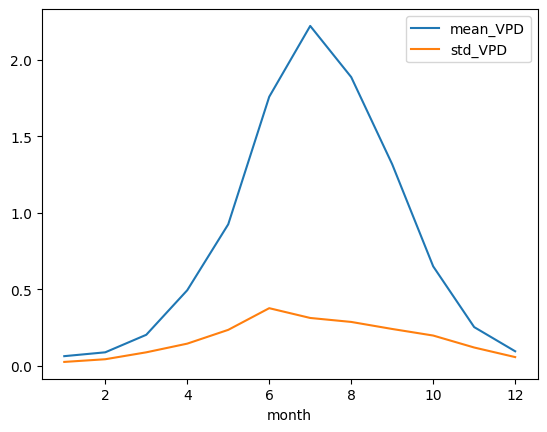

In [51]:
monthly_stats_por.plot()